# Personal Gym Supplements RAG

Same RAGWire pipeline as Module 2 — different domain, different data, different system prompt.
This shows how little needs to change to go from finance to health.

**Model:** `gemini-2.5-flash` (Google) · **Embedding:** `gemini-embedding-001` (Google) · **Vector Store:** Qdrant Cloud

## 1. Setup and Ingest

In [2]:
from dotenv import load_dotenv
load_dotenv(override=True)

from ragwire import RAGWire, setup_logging
import ragwire

logger = setup_logging(log_level="INFO")
print(ragwire.__version__)



1.2.7


In [5]:
rag = RAGWire('config_gemini_qdrant.yaml')

2026-04-12 00:31:33,382 - ragwire.core.pipeline - INFO - Loading configuration from config_gemini_qdrant.yaml
2026-04-12 00:31:33,406 - ragwire.core.pipeline - INFO - Document loader initialized
2026-04-12 00:31:33,407 - ragwire.core.pipeline - INFO - Text splitter initialized (strategy=markdown, chunk_size=10000)
2026-04-12 00:31:33,409 - ragwire.core.pipeline - INFO - Embedding model initialized (provider=google)
2026-04-12 00:31:33,414 - ragwire.core.pipeline - INFO - Metadata extractor loaded from: health_metadata.yaml
2026-04-12 00:31:33,415 - ragwire.core.pipeline - INFO - LLM initialized for metadata extraction (provider=google, model=gemini-2.5-flash)
2026-04-12 00:31:33,427 - ragwire.vectorstores.qdrant_store - INFO - Connected to Qdrant at https://a432d78b-1429-48dd-b910-31d2d5c8b296.sa-east-1-0.aws.cloud.qdrant.io:6333
2026-04-12 00:31:35,217 - ragwire.vectorstores.qdrant_store - INFO - Created collection 'health-rag-google-qdrant' with hybrid search
2026-04-12 00:31:35,218 

In [6]:
rag.ingest_directory('../data/health_data')

2026-04-12 00:31:57,288 - ragwire.core.pipeline - INFO - Found 11 file(s) in ../data/health_data
2026-04-12 00:31:57,288 - ragwire.core.pipeline - INFO - Starting ingestion of 11 documents


Ingesting:   0%|          | 0/11 [00:00<?, ?file/s]

2026-04-12 00:32:17,800 - ragwire.core.pipeline - INFO - Processed ..\data\health_data\01_Elite_Athletes_Supplements_2025.pdf: 26 chunks


Ingesting:   9%|▉         | 1/11 [00:20<03:25, 20.51s/file]

2026-04-12 00:32:32,301 - ragwire.core.pipeline - INFO - Processed ..\data\health_data\02_Creatine_Supplementation_2024.pdf: 9 chunks


...

Ingesting:  91%|█████████ | 10/11 [01:55<00:08,  8.35s/file]

2026-04-12 00:33:55,880 - ragwire.core.pipeline - INFO - Processed ..\data\health_data\12_Protein_Supplementation_Review_2024.pdf: 1 chunks


Ingesting: 100%|██████████| 11/11 [01:58<00:00, 10.78s/file]


2026-04-12 00:34:01,068 - ragwire.core.pipeline - INFO - Ingestion complete: 10/11 documents


{'total': 11,
 'processed': 10,
 'skipped': 1,
 'failed': 0,
 'chunks_created': 75,
 'errors': []}

## 2. Basic Retrieval

In [7]:
rag.retrieve("protein", top_k=3)

2026-04-12 00:35:44,495 - ragwire.core.pipeline - INFO - Retrieved 3 documents for query: protein...


[Document(metadata={'source': '..\\data\\health_data\\02_Creatine_Supplementation_2024.pdf', 'file_name': '02_Creatine_Supplementation_2024.pdf', 'file_type': 'pdf', 'file_hash': '77af2964511c58d7235326513c5fbb010ad48f324418f1014994abb82cce51a5', 'chunk_id': '77af2964511c58d7235326513c5fbb010ad48f324418f1014994abb82cce51a5_0', 'chunk_hash': '80c9789434f6165624d4ec908628b0bb39b3ac4a074914a7b31d196bfb9963a0', 'chunk_index': 0, 'total_chunks': 9, 'created_at': '2026-04-11T19:02:26.631030+00:00', 'title': 'effects of different dietary supplements combined with conditioning training on muscle strength, jump performance, sprint speed, and muscle mass in athletes: a systematic review and network meta-analysis.', 'authors': ['beiwang deng', 'ruixiang yan', 'tianyuan he', 'gesheng lin', 'ting liu', 'wen chen', 'jiaxin he', 'duanying li'], 'publication_year': 2025, 'research_focus': ['muscle-strength', 'performance', 'sprint-speed', 'muscle-mass', 'nutrition'], '_id': 'e8c6954f-1a9b-42a5-8978-9b

In [8]:
rag.retrieve("what are the benefits of vitamin d?", top_k=3)

2026-04-12 00:36:41,691 - ragwire.core.pipeline - INFO - Retrieved 3 documents for query: what are the benefits of vitamin d?...


[Document(metadata={'source': '..\\data\\health_data\\03_Vitamin_D_Performance_2024.pdf', 'file_name': '03_Vitamin_D_Performance_2024.pdf', 'file_type': 'pdf', 'file_hash': '99802bd81e27a7cde5508eeedaad515bac3bb16c6e12b63e94219fd9cd5b59ae', 'chunk_id': '99802bd81e27a7cde5508eeedaad515bac3bb16c6e12b63e94219fd9cd5b59ae_3', 'chunk_hash': '1366bceff4849e6f860054a3fbed33bcf6495237766dc553a16af767ee66a5ff', 'chunk_index': 3, 'total_chunks': 8, 'created_at': '2026-04-11T19:02:39.614746+00:00', 'title': 'effect of vitamin d on athletic performance: a systematic review', 'authors': ['nader maai', 'florian a. frank', 'arthur meuris', 'nando ferreira'], 'publication_year': 2025, 'research_focus': ['vitamin-d', 'athletic-performance', 'supplementation', 'recovery', 'muscle-recovery'], '_id': '9d96fee0-3400-4c33-9b91-78b3ee208017', '_collection_name': 'health-rag-google-qdrant'}, page_content='25(OH)D, body\ncomposition,\nstrength/power,\nanabolic\nhormones\n\n25(OH)D,\nmuscle\nbiomarkers\n(troponi

## 3. Agent

Same two tools from Module 2 (`get_filter_context`, `search_documents`).
The only difference: the system prompt is tuned for a health and fitness assistant.

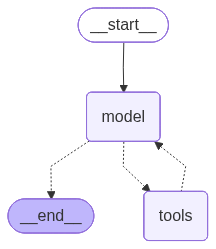

In [10]:
from langchain.agents import create_agent
from langchain.tools import tool
from langchain.messages import HumanMessage
from langchain_ollama import ChatOllama
from langgraph.checkpoint.memory import InMemorySaver
from langchain_google_genai import ChatGoogleGenerativeAI

@tool
def get_filter_context(query: str) -> str:
    """Get available metadata fields, stored values, and filter suggestions for a query.

    Call this before search_documents when the query involves a specific company,
    year, or document type. Skip for purely semantic queries.
    """
    return rag.get_filter_context(query)

@tool
def search_documents(query: str, filters=None):
    """Search the document knowledge base for relevant information.

    Args:
        query: The search query
        filters: Optional metadata filters from get_filter_context.
    """

    results = rag.retrieve(query=query, filters=filters)

    if not results:
        return "No relevant information is found!"
    else:
        return results 
    
# model = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite-preview")

agent = create_agent(
    model=ChatGoogleGenerativeAI(model="gemini-2.5-flash"),
    tools=[get_filter_context, search_documents],
    system_prompt="""You are a helpful health and fitness assistant.
                    For complex questions, break them down into simple sub-questions.
                    Always use search_documents to retrieve information — never answer from general knowledge.
                    Use get_filter_context before search_documents when the query involves specific metadata.
                    Always cite the source document in your answer.""",
    
    checkpointer=InMemorySaver(),
)

agent



## 4. Interactive Q&A

In [11]:
config = {"configurable": {"thread_id": "demo"}}

print("\nRAG Agent ready. Type 'quit' to exit.\n")

while True:
    question = input("You: ").strip()
    if question.lower() in ("quit", "exit", "q"):
        break
    if not question:
        continue
    response = agent.invoke(
        {"messages": [HumanMessage(question)]},
        config=config,
    )
    print(f"\nAgent: {response['messages'][-1].text}\n")


RAG Agent ready. Type 'quit' to exit.

2026-04-12 00:44:05,758 - ragwire.core.pipeline - INFO - Retrieved 5 documents for query: benefits of vitamin d...

Agent: Vitamin D supplementation can offer several benefits, particularly for athletes with initially low vitamin D levels:

*   **Increased Vitamin D Levels:** Supplementation consistently elevates serum 25(OH)D levels (Maai et al., 2025).
*   **Improved Athletic Performance (in deficient individuals):** For athletes with low baseline vitamin D, supplementation has been linked to significant improvements in power, strength, and aerobic capacity (Maai et al., 2025). Specific improvements noted include:
    *   Enhanced fat-free mass and some aspects of strength/power, such as deadlift and vertical jump (Maai et al., 2025).
    *   Improvements in 1-RM bench press, leg press, vertical jump, and 30m sprint times (Close et al., 2013; Fairbairn et al., 2018; Maai et al., 2025).
    *   Increased VO2max, PWC170, and lactate threshold (Ja